In [12]:
import numpy as np

from numpy.typing import NDArray
from numpy import float64

import gaussian.surrogate.gp as gp

mat1: NDArray[float64]  = np.array([.0, .1, .2, .3, .4])
mat2: NDArray[float64]  = np.array([.05, .15, .25, .35, .45])
y:    NDArray[float64]  = np.random.random((5,1))

(mean, cov, lmm) = gp.gaussian_surrogate(
    mat1=mat1,
    mat2=mat2,
    y=y,
    kernel=gp.squared_exponential,
    l=0.01,
    noise_var=0.1
)

print(mean)
print(cov)
print(lmm)



[[3.29732536e-06]
 [3.49753019e-06]
 [4.74178426e-06]
 [5.26720501e-06]
 [3.03128535e-06]]
[[ 1.00000000e+00 -1.26254035e-11  2.21374956e-33 -3.88160829e-55
   6.80604673e-77]
 [-1.26254035e-11  1.00000000e+00 -1.26254035e-11  2.21374956e-33
  -3.88160829e-55]
 [ 2.21374956e-33 -1.26254035e-11  1.00000000e+00 -1.26254035e-11
   2.21374956e-33]
 [-3.88160829e-55  2.21374956e-33 -1.26254035e-11  1.00000000e+00
  -1.26254035e-11]
 [ 6.80604673e-77 -3.88160829e-55  2.21374956e-33 -1.26254035e-11
   1.00000000e+00]]
[[-5.8930076]]


In [13]:
def gp(hyperparameters: NDArray[float64]):
    

_IncompleteInputError: incomplete input (845145824.py, line 2)

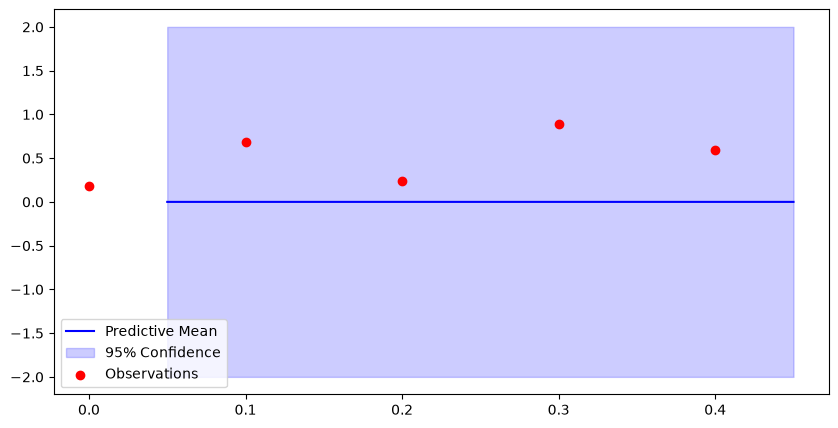

In [ ]:
import matplotlib.pyplot as plt


def plot_gp(X_train, y_train, X_test, mu, cov):
    variance = np.diag(cov)
    std = np.sqrt(variance)
    
    plt.figure(figsize=(10, 5))
    plt.plot(X_test.flatten(), mu.flatten(), 'b-', label='Predictive Mean')
    
    plt.fill_between(
        X_test.flatten(), 
        (mu.flatten() - 2 * std), 
        (mu.flatten() + 2 * std), 
        color='blue', alpha=0.2, label='95% Confidence'
    )
    
    plt.scatter(X_train.flatten(), y_train.flatten(), c='red', label='Observations')
    
    plt.legend()
    plt.show()

plot_gp(
    X_train=mat1,
    y_train=y,
    X_test=mat2,

    mu=mean,
    cov=cov
)